In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor

In [7]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing(as_frame=True)

df = data.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
X = df.drop('MedHouseVal', axis=1)  
y = df['MedHouseVal']

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

## Линейная регрессия (а вдруг линейная связь сработает)

In [11]:

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [12]:
print("Коэффициенты линейной регрессии:")
for feature, coef in zip(X.columns, lr.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"\nСвободный член (intercept): {lr.intercept_:.4f}")

Коэффициенты линейной регрессии:
MedInc: 0.8524
HouseAge: 0.1224
AveRooms: -0.3051
AveBedrms: 0.3711
Population: -0.0023
AveOccup: -0.0366
Latitude: -0.8966
Longitude: -0.8689

Свободный член (intercept): 2.0679


Можно объяснить как изменяется целевая переменная при изменении признака на 1 (после стандартизации).Положительный коэффициент - положительная зависимость, отрицательный - отрицательная

## Дерево решений

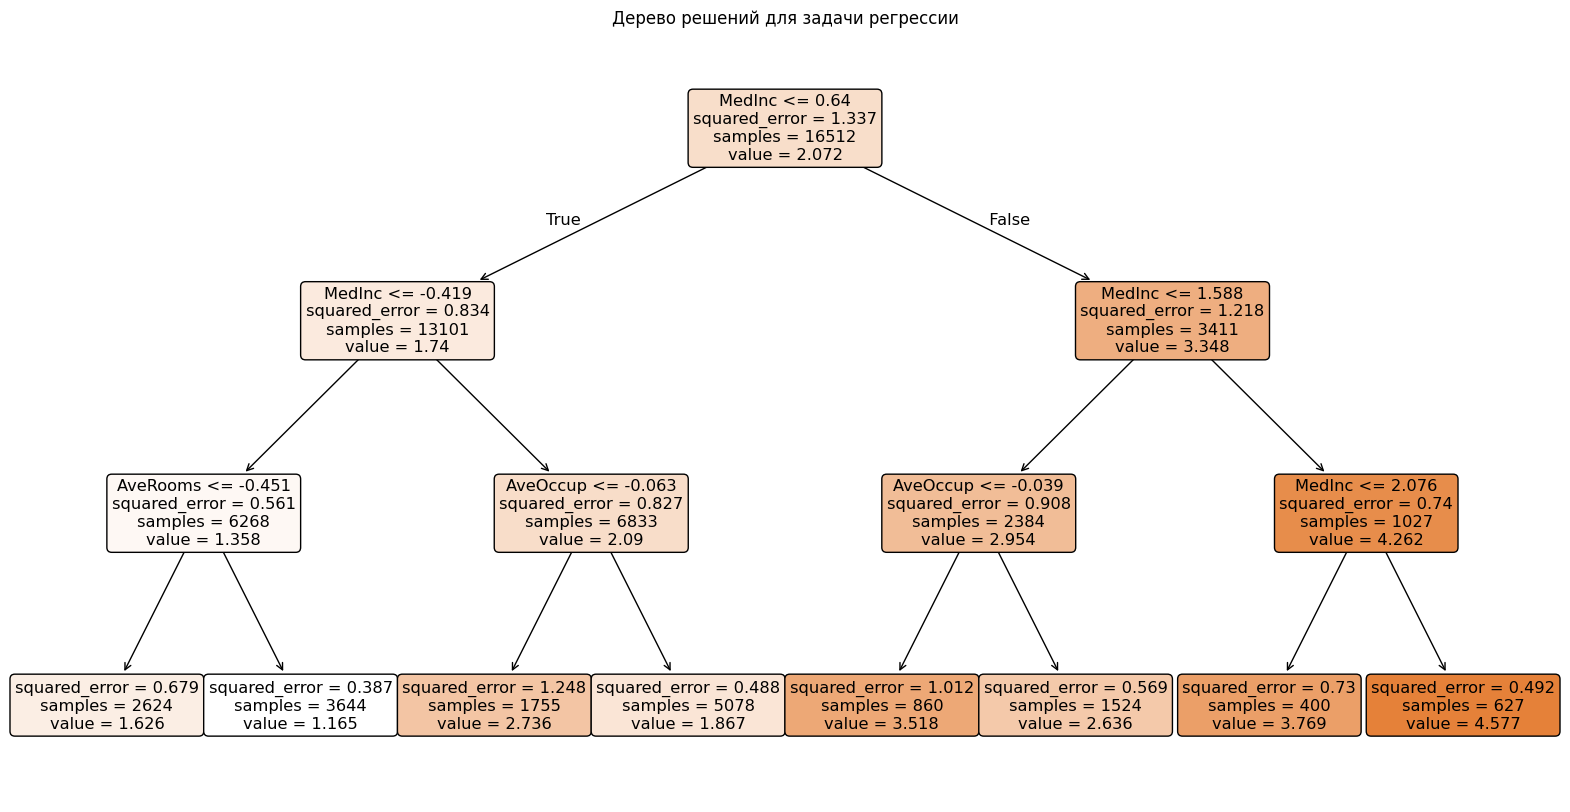

In [13]:
dtr = DecisionTreeRegressor(max_depth=3, random_state=42)
dtr.fit(X_train, y_train)


y_pred_dtr = dtr.predict(X_test)

#дерево решений
plt.figure(figsize=(20, 10))
plot_tree(dtr, filled=True, feature_names=X.columns, rounded=True)
plt.title("Дерево решений для задачи регрессии")
plt.show()

С помощью дерева также можно объяснить работу модели

## Градиентный бустинг (можно взять и catboost)

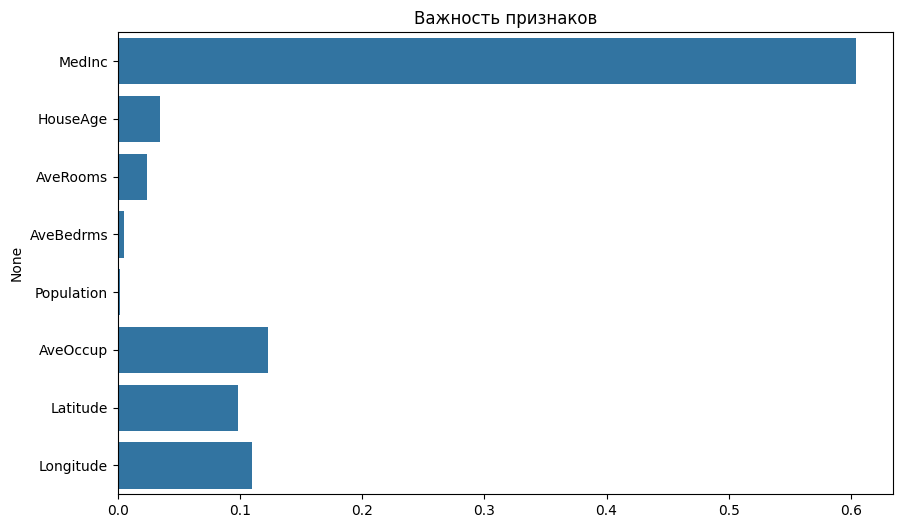

In [17]:
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

# важность признаков
feature_importance = gb.feature_importances_
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance, y=X.columns)
plt.title("Важность признаков")
plt.show()

In [19]:
#функция для оценки модели
def evaluate_model(y_true, y_pred_list, model_list):
    df_result = pd.DataFrame(columns= ['model','mae','rmse','r2'])
    for i,k in zip(y_pred_list, model_list):
        mae = mean_absolute_error(y_true, i)
        mse = mean_squared_error(y_true, i)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true, i)
        df_result.loc[len(df_result)]=[k,mae,rmse,r2]
    return df_result

In [20]:
df_result = evaluate_model(y_test,[y_pred_lr,y_pred_dtr,y_pred_gb],['Линейная регрессия','Дерево решений','Градиентный бустинг'])
df_result

,model,mae,rmse,r2
0,Линейная регрессия,0.533200,0.745581,0.575788
1,Дерево решений,0.597828,0.801505,0.509763
2,Градиентный бустинг,0.371650,0.542217,0.775643


По результатам анализа качества моделей по всем метрикам лучшей оказалась модель на базе Градиентного бустинга. Попробуем протюнить её параметры с целью получения оптимальных значений

In [25]:
gb = GradientBoostingRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    # 'max_depth': [3, 4, 5],
    # 'min_samples_split': [2, 5],
    # 'min_samples_leaf': [1, 2],
    # 'subsample': [0.8, 1.0]
}

In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

In [26]:
scoring = {
    'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
    'MSE': make_scorer(mean_squared_error, greater_is_better=False),
    'R2': make_scorer(r2_score)
}

In [27]:
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    scoring=scoring,
    refit='R2',
    cv=3, 
    n_jobs=-1,  
    verbose=2  
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


GridSearchCV(cv=3, estimator=GradientBoostingRegressor(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'n_estimators': [100, 200, 300]},
             refit='R2',
             scoring={'MAE': make_scorer(mean_absolute_error, greater_is_better=False, response_method='predict'),
                      'MSE': make_scorer(mean_squared_error, greater_is_better=False, response_method='predict'),
                      'R2': make_scorer(r2_score, response_method='predict')},
             verbose=2)

In [28]:
print("Лучшие параметры:", grid_search.best_params_)
print("Лучший R2-score:", grid_search.best_score_)

Лучшие параметры: {'learning_rate': 0.1, 'n_estimators': 300}
Лучший R2-score: 0.8141375504634795


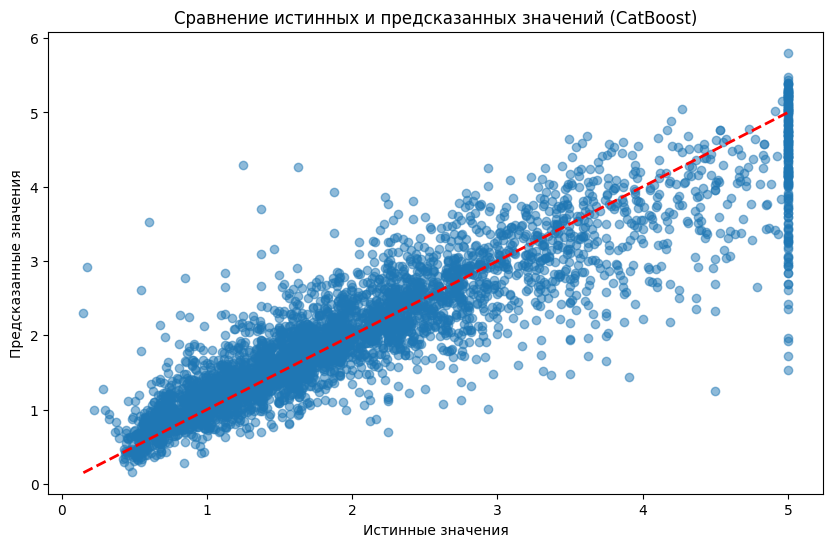

In [29]:
best_gb = grid_search.best_estimator_
y_pred = best_gb.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)
plt.xlabel("Истинные значения")
plt.ylabel("Предсказанные значения")
plt.title("Сравнение истинных и предсказанных значений (CatBoost)")
plt.show()